<a href="https://colab.research.google.com/github/changyunyeong/Histogram-based-Image-Enhancement/blob/main/Histogram-based%20Image%20Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

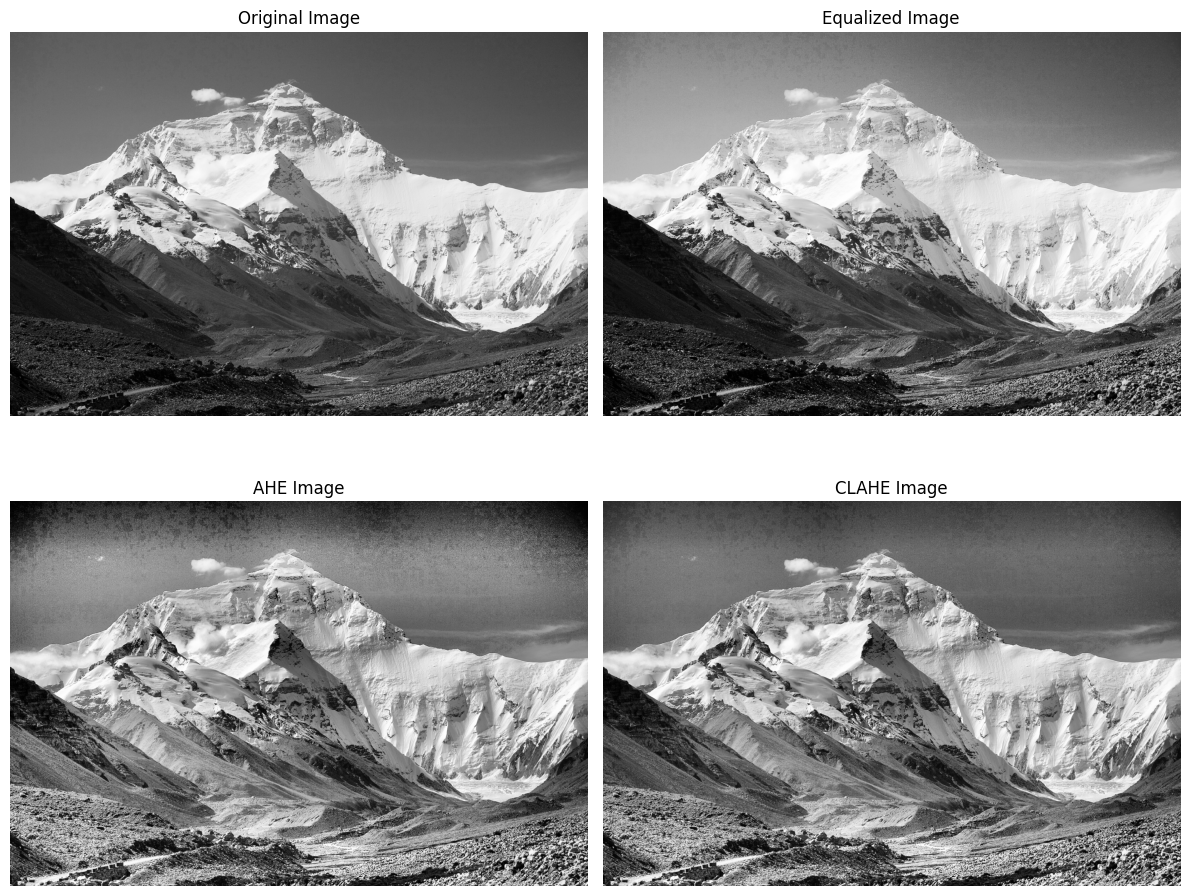

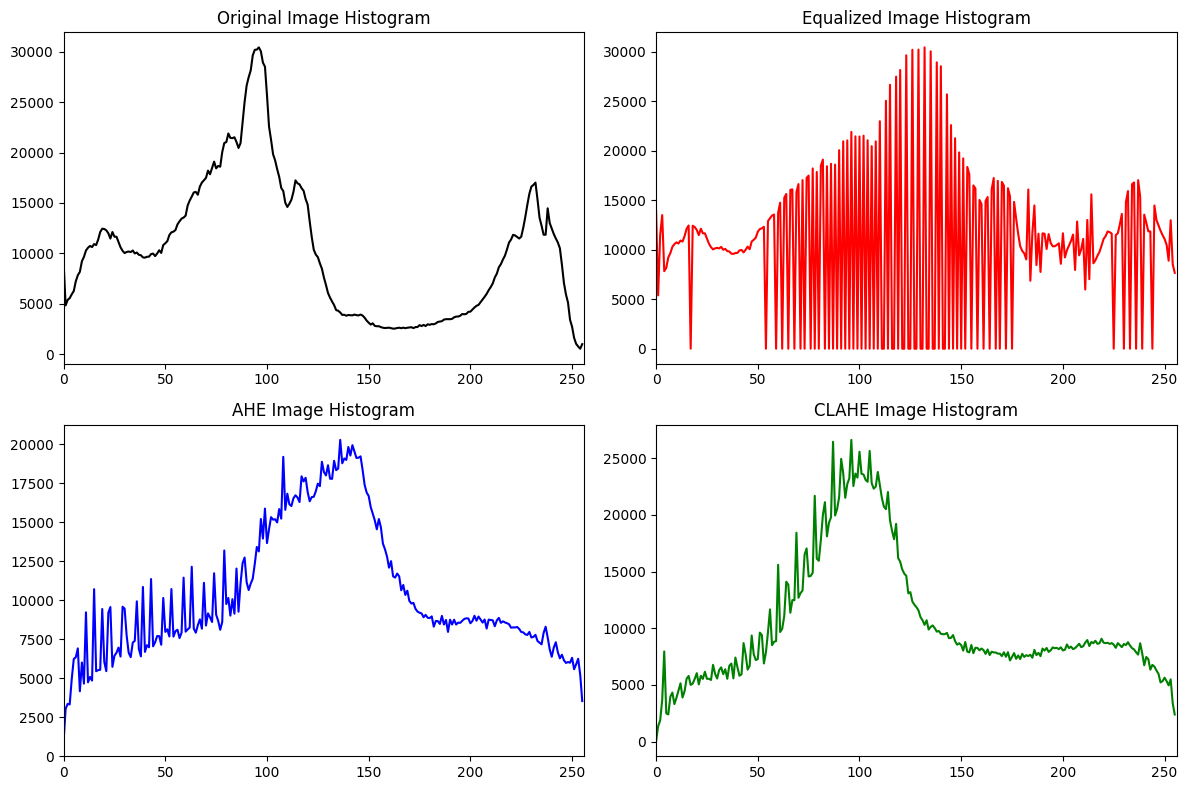

[Equalized Image]
PSNR : 19.54953904482791
SSIM : 0.9058617520589034
MSE :  721.3174793698424

[AHE Image]
PSNR : 13.709858052920083
SSIM : 0.610029281586063
MSE :  2767.544135783946

[CLAHE Image]
PSNR : 15.097270761313307
SSIM : 0.7171017914007015
MSE :  2010.7278105776445



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# 1. 이미지 로드
img = cv2.imread('/content/image-photoaidcom-greyscale.jpg')

dst = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

# 2. Histogram Equalization
img_eq = dst.copy()
img_eq[:, :, 0] = cv2.equalizeHist(img_eq[:, :, 0])
img_eq = cv2.cvtColor(img_eq, cv2.COLOR_YCrCb2BGR)

# 3. AHE
img_ahe = dst.copy()
ahe = cv2.createCLAHE(clipLimit=0.0, tileGridSize=(4, 4))
img_ahe[:, :, 0] = ahe.apply(img_ahe[:, :, 0])
img_ahe = cv2.cvtColor(img_ahe, cv2.COLOR_YCrCb2BGR)

# 4. CLAHE
img_clahe = dst.copy()
clahe = cv2.createCLAHE(clipLimit=4, tileGridSize=(4, 4))
img_clahe[:, :, 0] = clahe.apply(img_clahe[:, :, 0])
img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_YCrCb2BGR)

def get_y_hist(image_bgr):
    ycrcb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YCrCb)
    y_channel = ycrcb[:, :, 0]
    hist = cv2.calcHist([y_channel], [0], None, [256], [0, 256])
    return hist

def show_images_2x2(images, titles):
    plt.figure(figsize=(12, 10))
    for i, (image, title) in enumerate(zip(images, titles), 1):
        plt.subplot(2, 2, i)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_hists_2x2(images, titles, colors):
    plt.figure(figsize=(12, 8))
    for i, (image, title, color) in enumerate(zip(images, titles, colors), 1):
        hist = get_y_hist(image)
        plt.subplot(2, 2, i)
        plt.plot(hist, color=color)
        plt.title(f'{title} Histogram')
        plt.xlim([0, 256])
    plt.tight_layout()
    plt.show()

# MSE 계산
def calc_mse(img1, img2):
    return np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)

images = [img, img_eq, img_ahe, img_clahe]
titles = ['Original Image', 'Equalized Image', 'AHE Image', 'CLAHE Image']
colors = ['black', 'red', 'blue', 'green']

images = [img, img_eq, img_ahe, img_clahe]
titles = ['Original Image', 'Equalized Image', 'AHE Image', 'CLAHE Image']
colors = ['black', 'red', 'blue', 'green']

# 5. 이미지 4개 한 번에 출력
show_images_2x2(images, titles)

# 6. 히스토그램 4개 한 번에 출력
show_hists_2x2(images, titles, colors)

# 7. PSNR / SSIM 출력
print("[Equalized Image]")
print("PSNR :", peak_signal_noise_ratio(img, img_eq, data_range=255))
print("SSIM :", structural_similarity(img, img_eq, data_range=255, channel_axis=-1))
print("MSE : ", calc_mse(img, img_eq))
print()

print("[AHE Image]")
print("PSNR :", peak_signal_noise_ratio(img, img_ahe, data_range=255))
print("SSIM :", structural_similarity(img, img_ahe, data_range=255, channel_axis=-1))
print("MSE : ", calc_mse(img, img_ahe))
print()

print("[CLAHE Image]")
print("PSNR :", peak_signal_noise_ratio(img, img_clahe, data_range=255))
print("SSIM :", structural_similarity(img, img_clahe, data_range=255, channel_axis=-1))
print("MSE : ", calc_mse(img, img_clahe))
print()

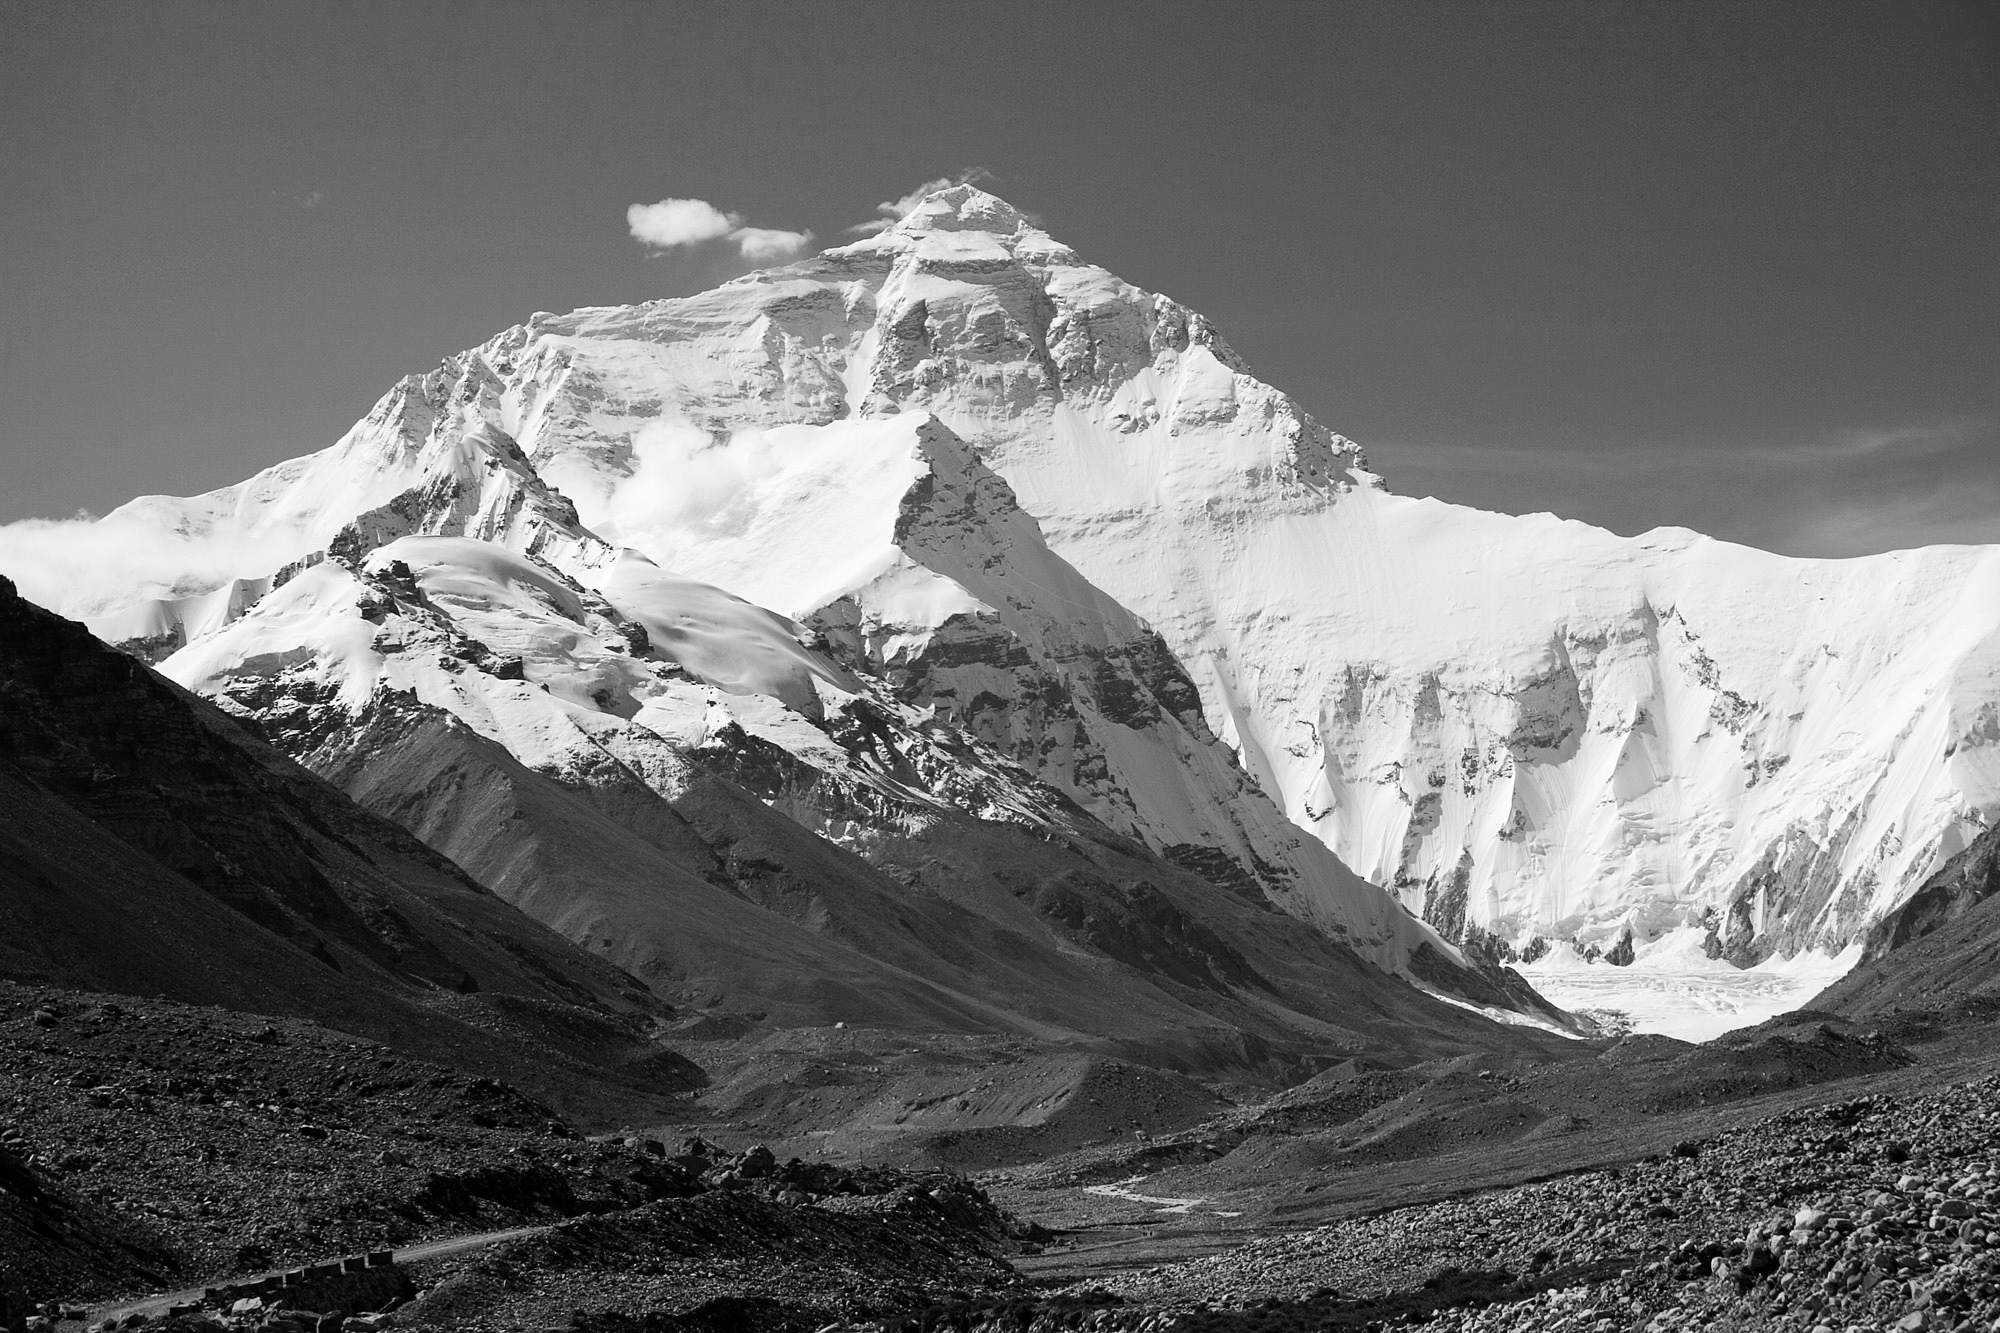

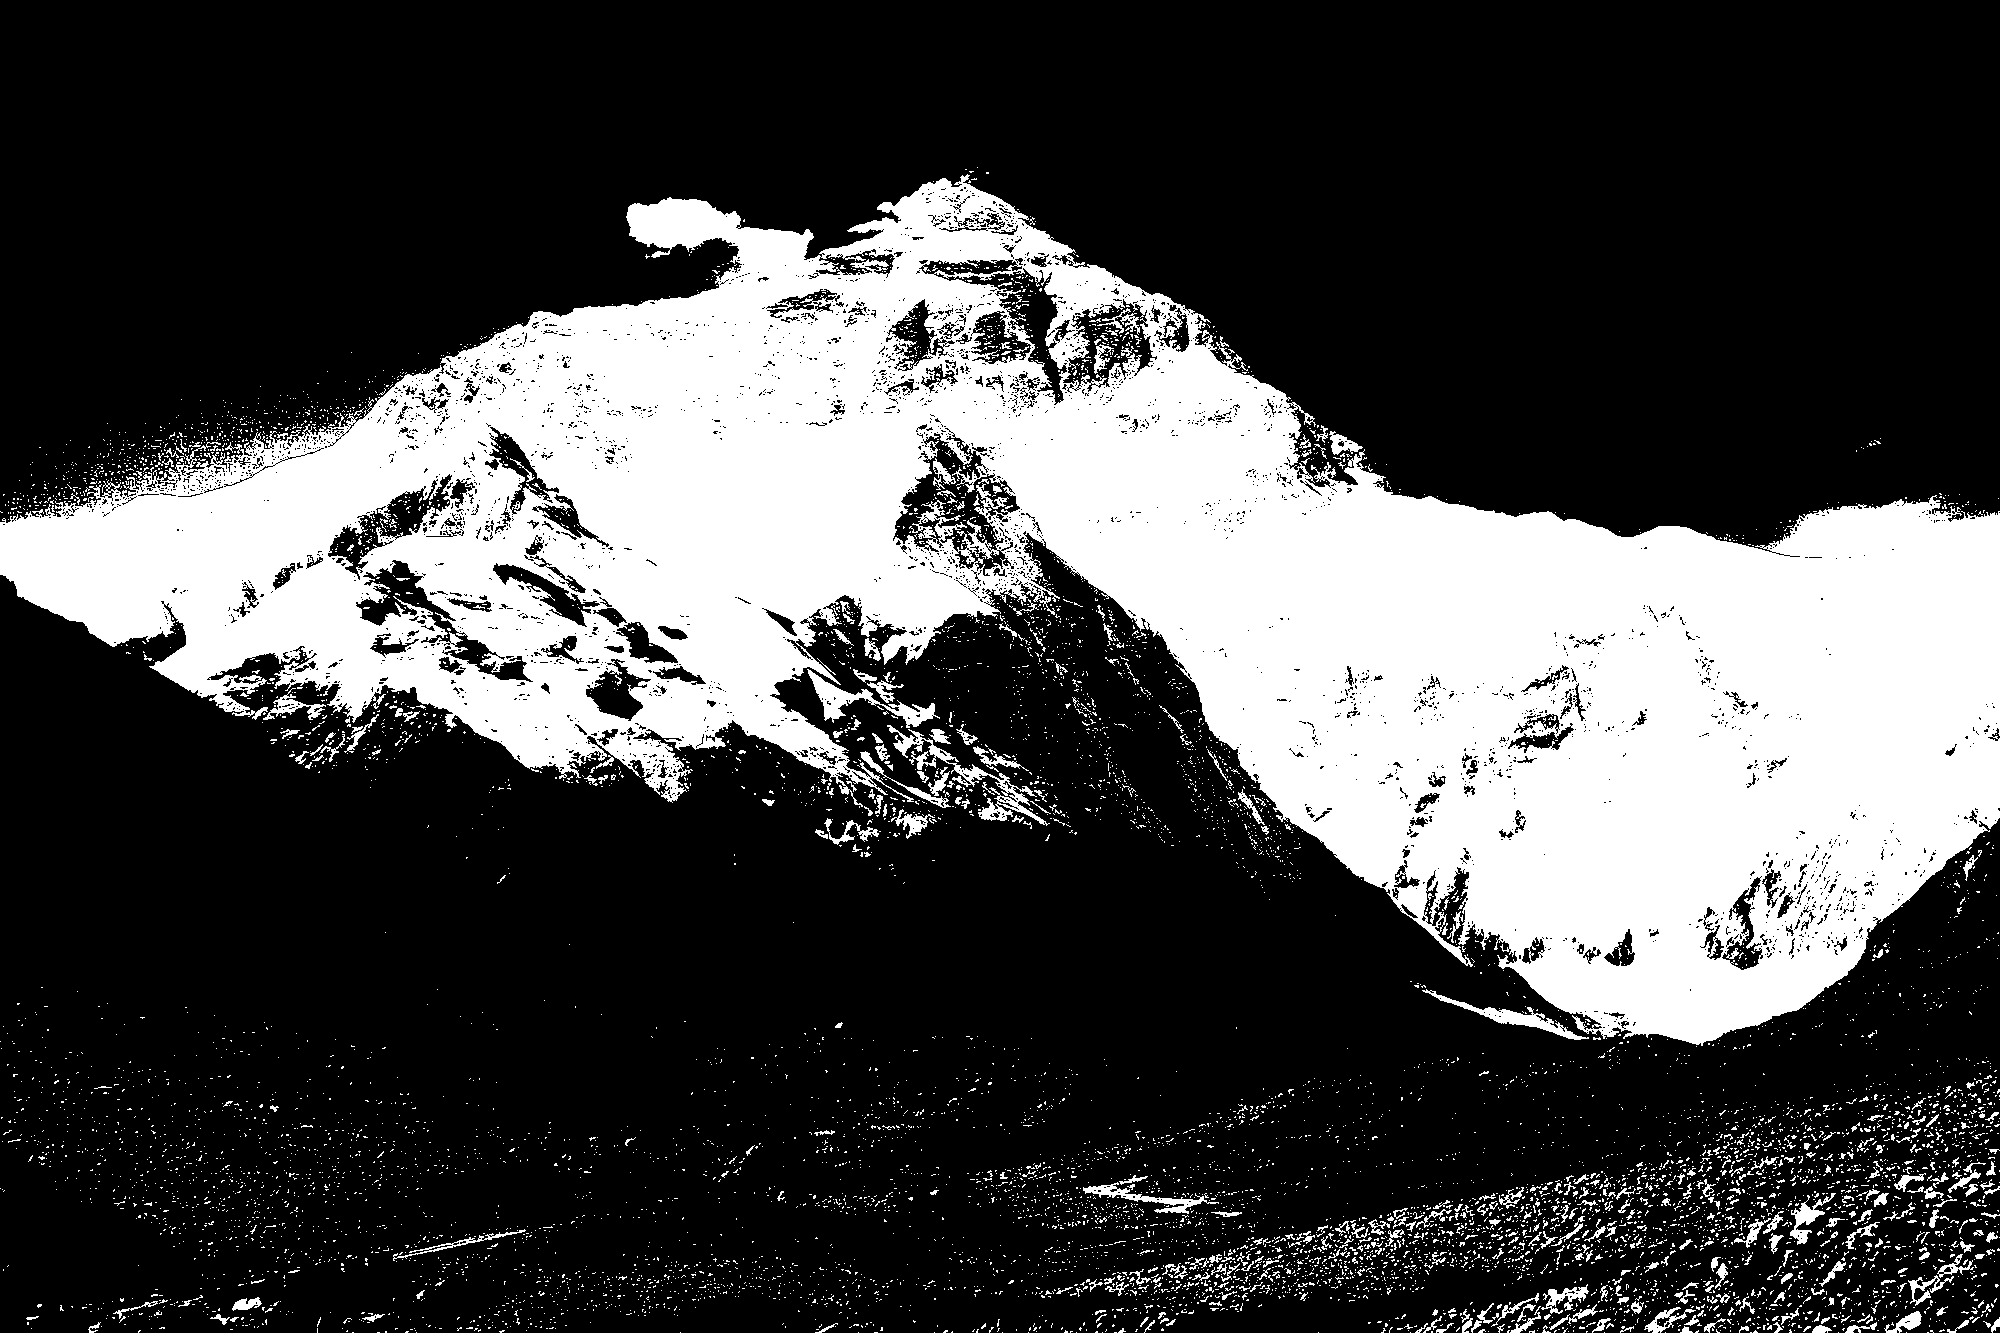

In [ ]:
# Binarization
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/image-photoaidcom-greyscale.jpg', cv2.IMREAD_GRAYSCALE)
ret, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
cv2_imshow(img)
cv2_imshow(th)